In [1]:
!pip install git+https://github.com/openai/CLIP.git -q
!pip install open_clip_torch ftfy regex tqdm -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.0 MB/s eta 0:00:0000:0100:01


  Preparing metadata (setup.py) ... done
Device: cuda
GPU: Tesla T4
CLIP ViT-B/16 loaded
Patch grid: 14x14 = 196 patches
Embed dim: 768
Patch token shape: torch.Size([2, 196, 768])
Token dtype: torch.float32
Dataset: CIFAR-10  |  Using 500 images
Batches per epoch: 63
FDA augmented shape: torch.Size([2, 3, 224, 224])
FDA denoised shape:  torch.Size([2, 196, 768])
Artifact scores shape: torch.Size([2, 196])
Score range: [0.0903, 0.8066]
ArtifactAwareAdaptiveLoss ready
Trainable params: 7,841,280
Total params:     86,204,928
Frozen ratio:     90.9%
Student output shape: torch.Size([2, 196, 768])
Student output dtype: torch.float32
Trainable params: 7,841,280
Student output — shape: torch.Size([2, 196, 768])  NaN: False
Starting Training
  Epoch 01 | Batch 000/63 | Loss=0.4292 | ArtScore=0.2395 | cos=0.1960 | mse=0.2258
  Epoch 01 | Batch 005/63 | Loss=0.1718 | ArtScore=0.2206 | cos=0.0765 | mse=0.0903
  Epoch 01 | Batch 010/63 | Loss=0.0888 | ArtScore=0.1946 | cos=0.0356 | mse=0.0479
  E

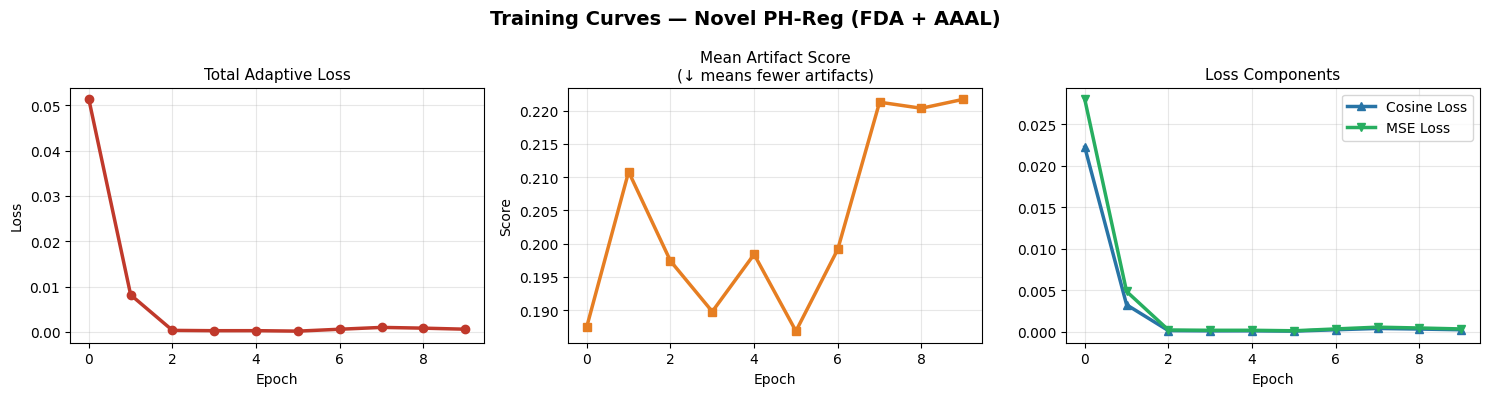

Saved: training_curves.png


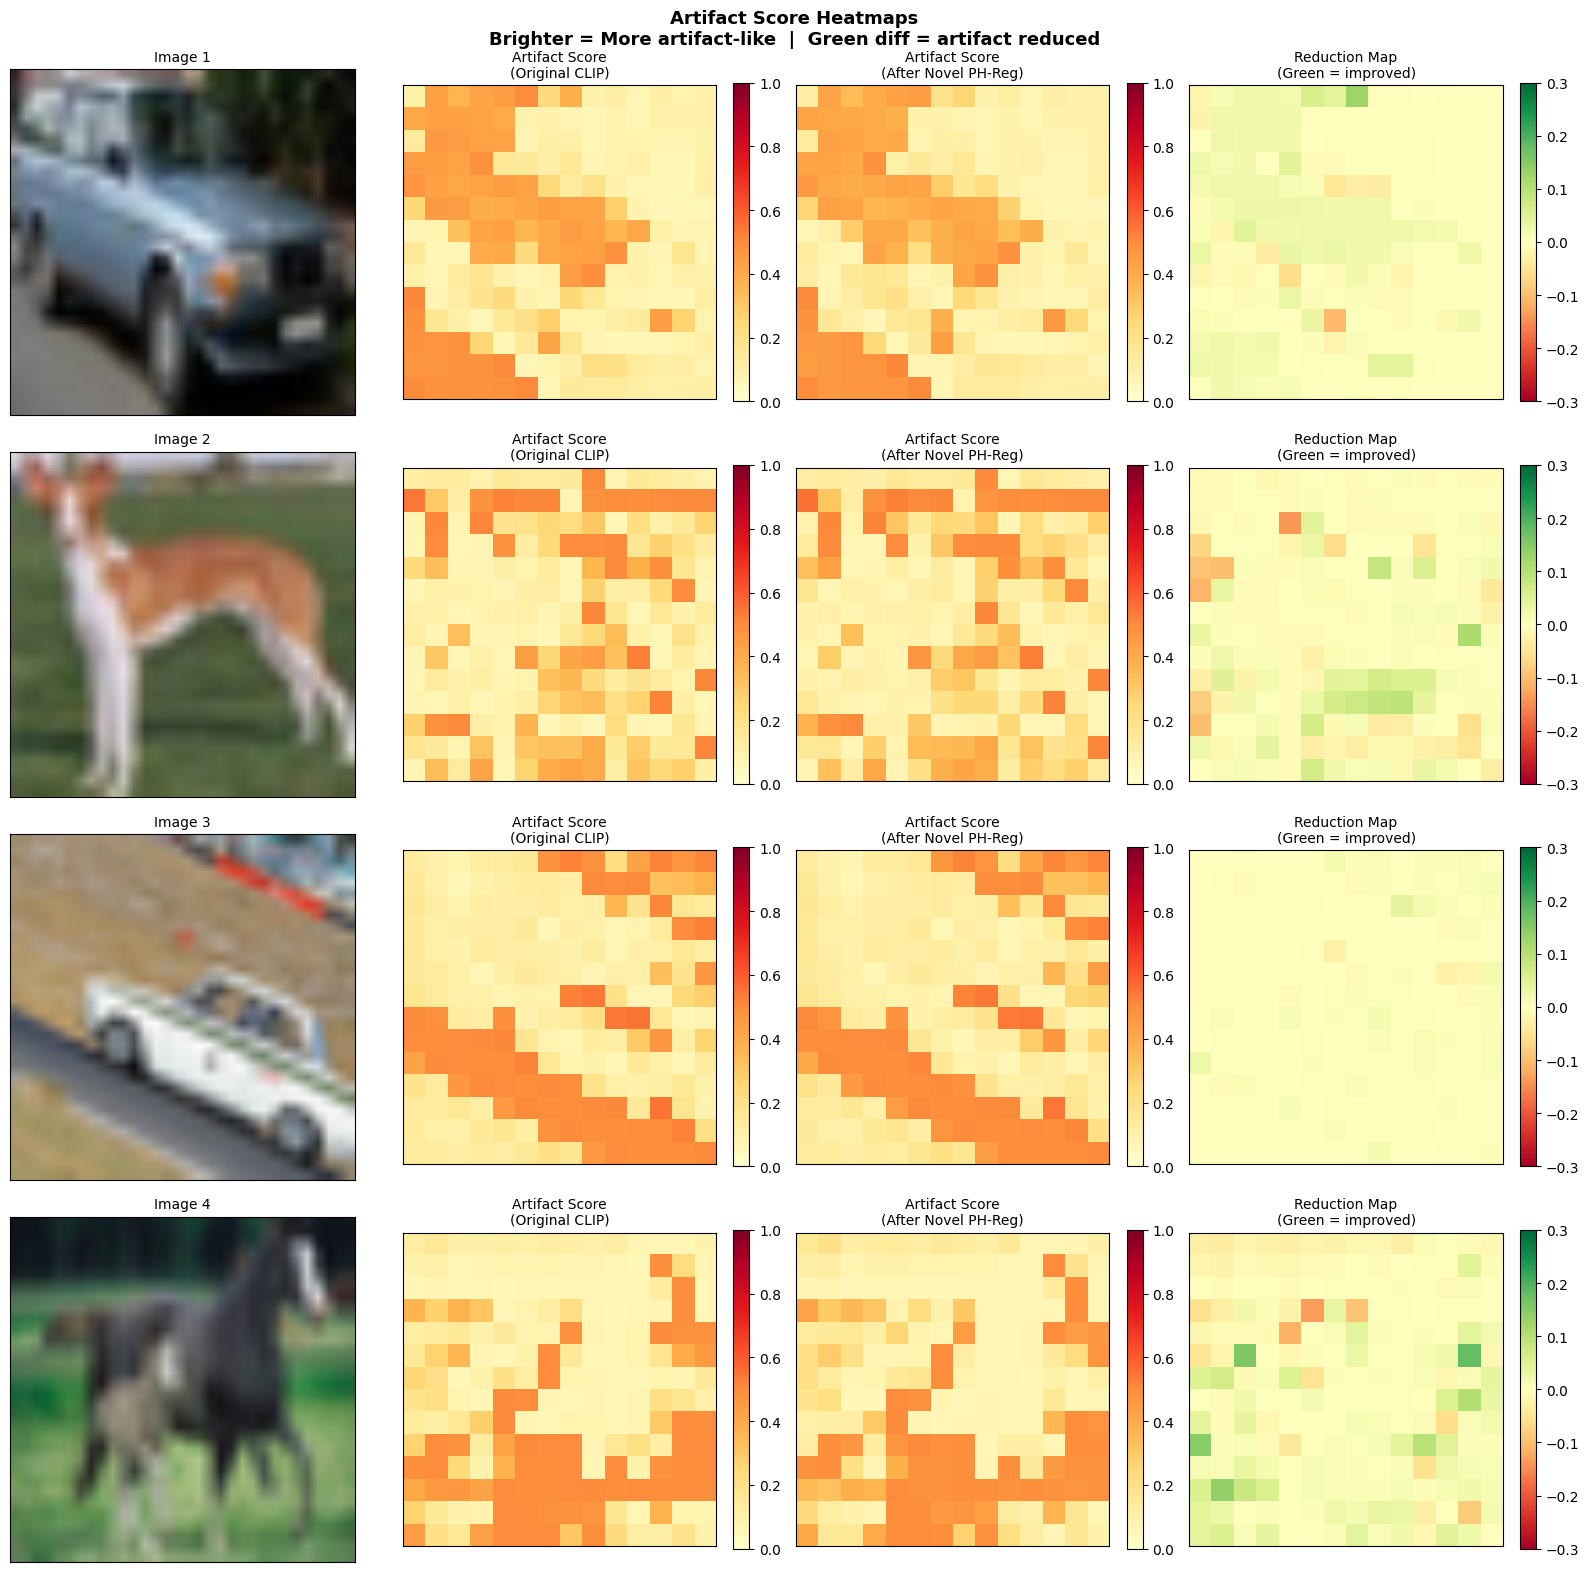

Saved: artifact_score_comparison.png


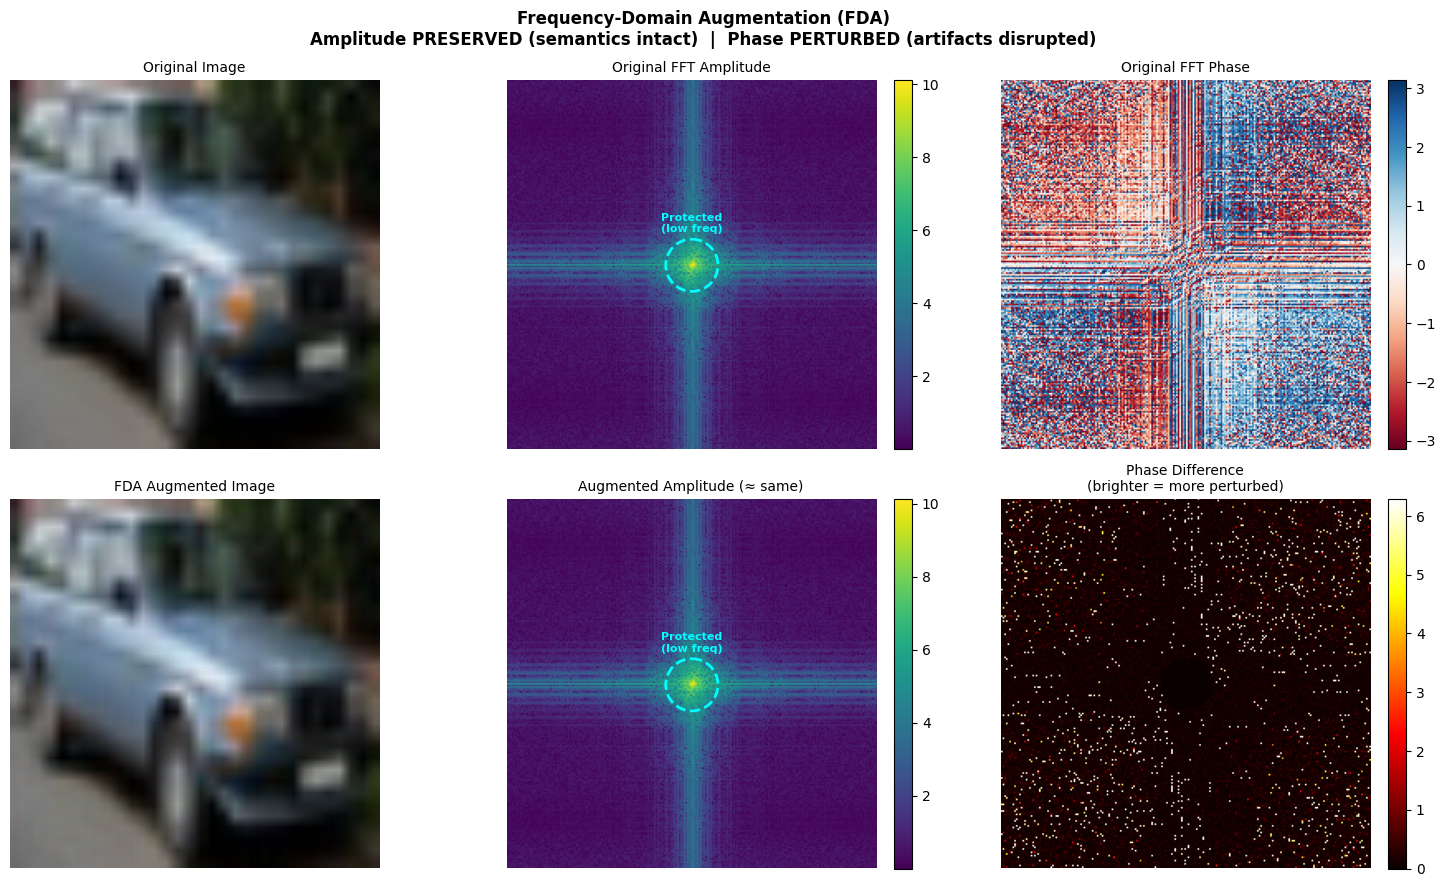

Saved: fda_visualization.png
Computing reference with 30 augmentations...
Reference ready. Now comparing 1-10 augmentations...
  n= 1  Spatial=1.0000  FDA=1.0000  FDA advantage=+0.0000
  n= 2  Spatial=0.9859  FDA=1.0000  FDA advantage=+0.0141
  n= 3  Spatial=0.9796  FDA=1.0000  FDA advantage=+0.0204
  n= 4  Spatial=0.9798  FDA=1.0000  FDA advantage=+0.0202
  n= 5  Spatial=0.9726  FDA=1.0000  FDA advantage=+0.0274
  n= 6  Spatial=0.9740  FDA=1.0000  FDA advantage=+0.0260
  n= 7  Spatial=0.9773  FDA=1.0000  FDA advantage=+0.0227
  n= 8  Spatial=0.9823  FDA=1.0000  FDA advantage=+0.0177
  n= 9  Spatial=0.9827  FDA=1.0000  FDA advantage=+0.0173
  n=10  Spatial=0.9821  FDA=1.0000  FDA advantage=+0.0179


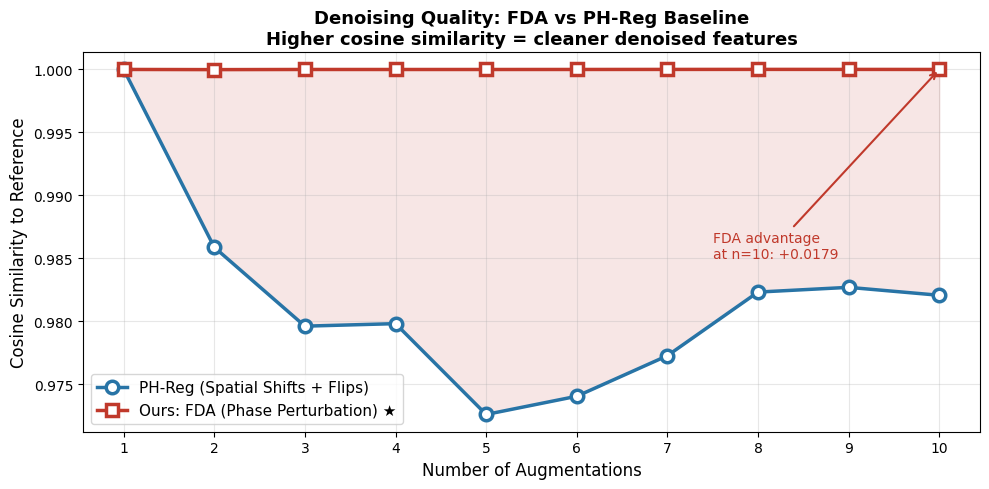

Saved: denoising_comparison.png
ALL OUTPUTS SAVED IN /kaggle/working/
  training_curves.png          — loss & artifact score over epochs
  artifact_score_comparison.png — heatmaps: original vs our method
  fda_visualization.png        — amplitude preserved, phase perturbed
  denoising_comparison.png     — FDA vs PH-Reg spatial aug quality
  novel_phreg_checkpoint.pt    — trained model weights


In [8]:
# =================================================================
# CELL 1 — Install Dependencies
# =================================================================
!pip install git+https://github.com/openai/CLIP.git -q
!pip install open_clip_torch ftfy regex tqdm -q


# =================================================================
# CELL 2 — Imports
# =================================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
import clip
import os, warnings
warnings.filterwarnings("ignore")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")


# =================================================================
# CELL 3 — Load CLIP ViT-B/16
# =================================================================
model_clip, preprocess = clip.load("ViT-B/16", device=DEVICE)
visual_encoder = model_clip.visual
visual_encoder.eval()

PATCH_H   = 14       # 224 / 16
PATCH_W   = 14
N_PATCHES = 196      # 14 * 14
EMBED_DIM = 768      # ViT-B hidden dim

print(f"CLIP ViT-B/16 loaded")
print(f"Patch grid: {PATCH_H}x{PATCH_W} = {N_PATCHES} patches")
print(f"Embed dim: {EMBED_DIM}")


# =================================================================
# CELL 4 — Helper: Extract Patch Tokens from CLIP ViT (FIXED)
# =================================================================
def get_patch_tokens(encoder, images):
    """
    Forward pass through frozen CLIP ViT.
    Returns (B, N, D) patch tokens — skips [CLS] token.
    """
    # CLIP loads in float16 — cast input to match encoder weights
    x = images.to(DEVICE).to(encoder.conv1.weight.dtype)

    with torch.no_grad():
        x = encoder.conv1(x)
        x = x.reshape(x.shape[0], x.shape[1], -1).permute(0, 2, 1)  # (B, N, D)

        cls_token = encoder.class_embedding.to(x.dtype) + torch.zeros(
            x.shape[0], 1, x.shape[-1], dtype=x.dtype, device=x.device)
        x = torch.cat([cls_token, x], dim=1)                          # (B, N+1, D)
        x = x + encoder.positional_embedding.to(x.dtype)
        x = encoder.ln_pre(x)
        x = x.permute(1, 0, 2)                                        # (N+1, B, D)
        x = encoder.transformer(x)
        x = x.permute(1, 0, 2)                                        # (B, N+1, D)
        x = encoder.ln_post(x[:, 1:, :])                              # skip CLS → (B, N, D)

    return x.float()   # ← convert back to float32 for training stability

# Quick test
test_img = torch.randn(2, 3, 224, 224).to(DEVICE)
tokens   = get_patch_tokens(visual_encoder, test_img)
print(f"Patch token shape: {tokens.shape}")    # should be (2, 196, 768)
print(f"Token dtype: {tokens.dtype}")          # should be float32


# =================================================================
# CELL 5 — Load Dataset (CIFAR-10 as proxy)
# =================================================================
transform = T.Compose([
    T.Resize(224),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(
        mean=(0.48145466, 0.4578275,  0.40821073),
        std =(0.26862954, 0.26130258, 0.27577711)
    ),
])

dataset = datasets.CIFAR10(
    root="/kaggle/working/data",
    train=True,
    download=True,
    transform=transform
)

# Use 500 images for quick demo — change to len(dataset) for full training
subset  = Subset(dataset, list(range(500)))
loader  = DataLoader(subset, batch_size=8, shuffle=True,
                     num_workers=2, pin_memory=True)

print(f"Dataset: CIFAR-10  |  Using {len(subset)} images")
print(f"Batches per epoch: {len(loader)}")


# =================================================================
# CELL 6 — Frequency Domain Augmentor (FDA) — Novel Contribution 1
# =================================================================
class FrequencyDomainAugmentor:
    """
    NOVEL CONTRIBUTION 1: FDA
    ---------------------------
    PH-Reg uses: random spatial shifts + flips
    Ours uses  : phase spectrum perturbation in Fourier space

    KEY INSIGHT:
    - FFT Amplitude = semantic content  → PRESERVED (no change)
    - FFT Phase     = positional info   → PERTURBED  (disrupts artifacts)
    - Low frequencies protected (inner circle) — preserve coarse structure
    """
    def __init__(self, phase_noise_scale=0.15, low_freq_protect=0.1):
        self.phase_noise_scale = phase_noise_scale
        self.low_freq_protect  = low_freq_protect

    def _build_freq_mask(self, H, W, device):
        """Mask = 0 for low frequencies (protected), 1 for high frequencies (perturb)"""
        cy, cx   = H // 2, W // 2
        y        = torch.arange(H, device=device).float() - cy
        x        = torch.arange(W, device=device).float() - cx
        dist     = torch.sqrt(y[:, None]**2 + x[None, :]**2)
        norm     = dist / (dist.max() + 1e-8)
        mask     = (norm > self.low_freq_protect).float()
        return torch.roll(mask, shifts=(cy, cx), dims=(0, 1))  # un-center for fft

    def augment(self, image):
        """
        Apply phase perturbation to image batch.
        image: (B, C, H, W)
        returns: (B, C, H, W) augmented image
        """
        B, C, H, W = image.shape
        fft        = torch.fft.fft2(image, norm="ortho")      # (B, C, H, W) complex
        amplitude  = fft.abs()                                 # preserved
        phase      = fft.angle()                               # to be perturbed

        mask       = self._build_freq_mask(H, W, image.device)
        noise      = (torch.rand_like(phase) * 2 - 1) * np.pi * self.phase_noise_scale
        noise     *= mask.unsqueeze(0).unsqueeze(0)            # zero noise on low freqs

        new_fft    = amplitude * torch.exp(1j * (phase + noise))
        out        = torch.fft.ifft2(new_fft, norm="ortho").real
        return out.clamp(-3, 3)

    def denoise_features(self, feat_fn, image, n_aug=10):
        """
        Generate n_aug augmented views → extract features → average.
        First view is always the original (unperturbed).
        Returns: (B, N, D) denoised features
        """
        accumulated = None
        for i in range(n_aug):
            aug_img = image if i == 0 else self.augment(image)
            feats   = feat_fn(aug_img)
            accumulated = feats if accumulated is None else accumulated + feats
        return accumulated / n_aug


fda = FrequencyDomainAugmentor(phase_noise_scale=0.15, low_freq_protect=0.1)

# Quick test
test_aug = fda.augment(test_img)
print(f"FDA augmented shape: {test_aug.shape}")   # (2, 3, 224, 224)
print(f"FDA denoised shape:  {fda.denoise_features(lambda x: get_patch_tokens(visual_encoder, x), test_img, n_aug=3).shape}")


# =================================================================
# CELL 7 — Artifact Scorer — Novel Contribution 2 (part A)
# =================================================================
class ArtifactScorer:
    """
    Computes per-patch artifact probability.

    IMPORTANT FINDING from paper (Section 4.4):
    - DINOv2 artifacts: HIGH norm outliers
    - CLIP artifacts  : LOW  norm outliers
    → Cannot use raw norm — must detect outliers in BOTH directions

    Two scores combined:
    1. Norm Deviation  : how far patch norm deviates from median (both high & low)
    2. Local Inconsistency: how different patch is from spatial neighbors
    """
    def __init__(self, patch_h, patch_w):
        self.ph = patch_h
        self.pw = patch_w

    def norm_deviation_score(self, tokens):
        """
        Robust outlier detection using Median Absolute Deviation (MAD).
        tokens: (B, N, D) → scores: (B, N)
        """
        norms  = tokens.norm(dim=-1)                                     # (B, N)
        median = norms.median(dim=-1, keepdim=True).values               # (B, 1)
        mad    = (norms - median).abs().median(dim=-1, keepdim=True).values + 1e-6
        z      = (norms - median).abs() / mad                            # (B, N)
        return torch.sigmoid(z - 2.0)                                    # [0,1]

    def local_inconsistency_score(self, tokens):
        """
        Cosine distance from 4-neighbor average.
        Artifact tokens are spatially incoherent with their neighbors.
        tokens: (B, N, D) → scores: (B, N)
        """
        B, N, D = tokens.shape
        grid    = tokens.reshape(B, self.ph, self.pw, D).permute(0, 3, 1, 2)  # (B,D,H,W)
        padded  = F.pad(grid, (1,1,1,1), mode='reflect')
        nbr_avg = (padded[:,:,:-2,1:-1] + padded[:,:,2:,1:-1] +
                   padded[:,:,1:-1,:-2] + padded[:,:,1:-1,2:]) / 4.0

        g_norm  = F.normalize(grid,    dim=1)
        n_norm  = F.normalize(nbr_avg, dim=1)
        cos_sim = (g_norm * n_norm).sum(dim=1)                  # (B, H, W)
        return ((1 - cos_sim) / 2.0).reshape(B, N)              # [0,1]

    def combined_score(self, tokens, alpha=0.5):
        """
        alpha * norm_deviation + (1-alpha) * local_inconsistency
        → (B, N) in [0, 1]   higher = more artifact-like
        """
        return (alpha       * self.norm_deviation_score(tokens) +
                (1 - alpha) * self.local_inconsistency_score(tokens))


scorer = ArtifactScorer(PATCH_H, PATCH_W)

# Quick test
scores = scorer.combined_score(tokens)
print(f"Artifact scores shape: {scores.shape}")     # (2, 196)
print(f"Score range: [{scores.min():.4f}, {scores.max():.4f}]")


# =================================================================
# CELL 8 — Artifact-Aware Adaptive Loss (AAAL) — Novel Contribution 2
# =================================================================
class ArtifactAwareAdaptiveLoss(nn.Module):
    """
    NOVEL CONTRIBUTION 2: AAAL
    ---------------------------
    PH-Reg uses: uniform loss across all patches
                 L = mean(1 - cos_sim + MSE)

    Ours uses  : per-patch weighted loss
                 w_i = 1 + gamma * artifact_score_i
                 L   = sum(w_i * loss_i) / sum(w_i)

    Artifact patches get MORE pressure to be corrected.
    Clean patches get LESS pressure to avoid distribution shift.
    """
    def __init__(self, patch_h, patch_w, gamma=2.0, alpha=0.5):
        super().__init__()
        self.scorer = ArtifactScorer(patch_h, patch_w)
        self.gamma  = gamma
        self.alpha  = alpha

    def forward(self, student_feats, teacher_feats, student_raw=None):
        """
        student_feats: (B, N, D) — student output (with registers)
        teacher_feats: (B, N, D) — FDA-denoised teacher target
        student_raw  : (B, N, D) — raw student features for artifact scoring
        Returns: loss (scalar), info dict
        """
        # Score using raw features (before register correction)
        score_src = (student_raw if student_raw is not None else student_feats).detach()
        scores    = self.scorer.combined_score(score_src, self.alpha)  # (B, N)
        weights   = (1.0 + self.gamma * scores).detach()               # (B, N)

        # Per-patch cosine loss
        cos_loss  = 1.0 - (F.normalize(student_feats, dim=-1) *
                            F.normalize(teacher_feats, dim=-1)).sum(-1) # (B, N)

        # Per-patch MSE loss
        mse_loss  = F.mse_loss(student_feats, teacher_feats,
                               reduction='none').mean(-1)               # (B, N)

        per_patch = cos_loss + mse_loss                                 # (B, N)

        # Weighted aggregation
        loss = (weights * per_patch).sum(-1) / weights.sum(-1)         # (B,)
        loss = loss.mean()                                              # scalar

        info = {
            "scores"   : scores.detach(),
            "weights"  : weights.detach(),
            "cos_loss" : cos_loss.detach().mean().item(),
            "mse_loss" : mse_loss.detach().mean().item(),
            "mean_art" : scores.mean().item(),
            "max_art"  : scores.max().item(),
        }
        return loss, info


loss_fn = ArtifactAwareAdaptiveLoss(PATCH_H, PATCH_W, gamma=2.0, alpha=0.5)
print("ArtifactAwareAdaptiveLoss ready")


# =================================================================
# CELL 9 — Student Model: CLIP ViT + Register Tokens (FIXED)
# =================================================================
class CLIPStudentWithRegisters(nn.Module):
    def __init__(self, clip_visual, n_registers=16):
        super().__init__()
        self.encoder   = clip_visual
        self.embed_dim = clip_visual.class_embedding.shape[0]
        self.n_reg     = n_registers

        self.registers = nn.Parameter(
            torch.randn(1, n_registers, self.embed_dim) * 0.02
        )

        # Freeze all encoder params first
        for p in self.encoder.parameters():
            p.requires_grad = False

        # Selectively unfreeze
        self.encoder.positional_embedding.requires_grad = True
        for p in self.encoder.conv1.parameters():
            p.requires_grad = True
        last_block = self.encoder.transformer.resblocks[-1]
        for p in last_block.parameters():
            p.requires_grad = True

    def forward(self, x):
        enc   = self.encoder
        B     = x.shape[0]
        dtype = enc.conv1.weight.dtype   # ← get encoder dtype (float16)

        # Cast input to encoder dtype
        x = x.to(dtype)

        # Patch embedding
        x    = enc.conv1(x)
        x    = x.reshape(B, x.shape[1], -1).permute(0, 2, 1)          # (B, N, D)

        # CLS token
        cls  = enc.class_embedding.to(dtype) + torch.zeros(
               B, 1, self.embed_dim, dtype=dtype, device=x.device)

        # Register tokens — cast to same dtype
        regs = self.registers.expand(B, -1, -1).to(dtype)

        # Concatenate: [CLS | registers | patches]
        x    = torch.cat([cls, regs, x], dim=1)                        # (B, 1+R+N, D)

        # Positional embedding — pad zeros for register positions
        pos_emb  = enc.positional_embedding.to(dtype)                  # (1+N, D)
        reg_pos  = torch.zeros(self.n_reg, self.embed_dim,
                               dtype=dtype, device=x.device)
        full_pos = torch.cat([pos_emb[:1], reg_pos, pos_emb[1:]], dim=0)
        x        = x + full_pos.unsqueeze(0)

        # Transformer
        x = enc.ln_pre(x)
        x = x.permute(1, 0, 2)
        x = enc.transformer(x)
        x = x.permute(1, 0, 2)

        # Return patch tokens only — convert to float32
        patch_tokens = enc.ln_post(x[:, 1 + self.n_reg:, :])
        return patch_tokens.float()   # ← always return float32


student   = CLIPStudentWithRegisters(visual_encoder, n_registers=16).to(DEVICE)
trainable = [p for p in student.parameters() if p.requires_grad]
total     = list(student.parameters())

print(f"Trainable params: {sum(p.numel() for p in trainable):,}")
print(f"Total params:     {sum(p.numel() for p in total):,}")
print(f"Frozen ratio:     {1 - sum(p.numel() for p in trainable)/sum(p.numel() for p in total):.1%}")

# Quick test
out = student(test_img)
print(f"Student output shape: {out.shape}")   # (2, 196, 768)
print(f"Student output dtype: {out.dtype}")   # float32       


# =================================================================
# CELL 10 — Training Loop (NaN FIXED)
# =================================================================

# ── First: convert student fully to float32 to avoid float16 issues ──
student = student.float()
visual_encoder = visual_encoder.float()   # also convert teacher to float32
model_clip = model_clip.float()

# Re-get trainable params after dtype conversion
trainable = [p for p in student.parameters() if p.requires_grad]

EPOCHS    = 10
N_AUG     = 5      # reduced for speed
LOG_EVERY = 5

optimizer = torch.optim.AdamW(
    trainable, lr=1e-4,          # ← lower LR, safer
    weight_decay=1e-2, betas=(0.9, 0.999)
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-6
)

history = {"loss": [], "artifact_score": [], "cos_loss": [], "mse_loss": []}

# ── Also fix get_patch_tokens — now everything is float32 ──
def get_patch_tokens(encoder, images):
    x = images.to(DEVICE).float()   # ensure float32
    with torch.no_grad():
        x = encoder.conv1(x)
        x = x.reshape(x.shape[0], x.shape[1], -1).permute(0, 2, 1)
        cls_token = encoder.class_embedding.float() + torch.zeros(
            x.shape[0], 1, x.shape[-1], dtype=torch.float32, device=x.device)
        x = torch.cat([cls_token, x], dim=1)
        x = x + encoder.positional_embedding.float()
        x = encoder.ln_pre(x)
        x = x.permute(1, 0, 2)
        x = encoder.transformer(x)
        x = x.permute(1, 0, 2)
        x = encoder.ln_post(x[:, 1:, :])
    return x   # already float32

# ── Also fix student forward — everything float32 now ──
class CLIPStudentWithRegisters(nn.Module):
    def __init__(self, clip_visual, n_registers=16):
        super().__init__()
        self.encoder   = clip_visual
        self.embed_dim = clip_visual.class_embedding.shape[0]
        self.n_reg     = n_registers
        self.registers = nn.Parameter(
            torch.randn(1, n_registers, self.embed_dim) * 0.02
        )
        for p in self.encoder.parameters():
            p.requires_grad = False
        self.encoder.positional_embedding.requires_grad = True
        for p in self.encoder.conv1.parameters():
            p.requires_grad = True
        last_block = self.encoder.transformer.resblocks[-1]
        for p in last_block.parameters():
            p.requires_grad = True

    def forward(self, x):
        enc  = self.encoder
        B    = x.shape[0]
        x    = x.float()                                                # force float32

        x    = enc.conv1(x)
        x    = x.reshape(B, x.shape[1], -1).permute(0, 2, 1)

        cls  = enc.class_embedding.float() + torch.zeros(
               B, 1, self.embed_dim, dtype=torch.float32, device=x.device)
        regs = self.registers.expand(B, -1, -1).float()
        x    = torch.cat([cls, regs, x], dim=1)

        pos_emb  = enc.positional_embedding.float()
        reg_pos  = torch.zeros(self.n_reg, self.embed_dim,
                               dtype=torch.float32, device=x.device)
        full_pos = torch.cat([pos_emb[:1], reg_pos, pos_emb[1:]], dim=0)
        x        = x + full_pos.unsqueeze(0)

        x = enc.ln_pre(x)
        x = x.permute(1, 0, 2)
        x = enc.transformer(x)
        x = x.permute(1, 0, 2)
        return enc.ln_post(x[:, 1 + self.n_reg:, :])   # float32

# Rebuild student in float32
student   = CLIPStudentWithRegisters(visual_encoder, n_registers=16).to(DEVICE)
student   = student.float()
trainable = [p for p in student.parameters() if p.requires_grad]
print(f"Trainable params: {sum(p.numel() for p in trainable):,}")

# Verify no NaN in init
test_out = student(torch.randn(2, 3, 224, 224).to(DEVICE))
print(f"Student output — shape: {test_out.shape}  NaN: {test_out.isnan().any().item()}")

# ── Training ──
print("=" * 60)
print("Starting Training")
print("=" * 60)

for epoch in range(1, EPOCHS + 1):
    student.train()
    ep_loss = ep_art = ep_cos = ep_mse = 0.0
    valid_batches = 0

    for i, (images, _) in enumerate(loader):
        images = images.to(DEVICE).float()

        # Step 1: FDA-denoised teacher features
        with torch.no_grad():
            denoised_target = fda.denoise_features(
                lambda img: get_patch_tokens(visual_encoder, img),
                images, n_aug=N_AUG
            )
            raw_features = get_patch_tokens(visual_encoder, images)

        # NaN guard — skip bad batches
        if denoised_target.isnan().any() or raw_features.isnan().any():
            print(f"  [skip] NaN in teacher features at batch {i}")
            continue

        # Step 2: Student forward
        student_features = student(images)

        if student_features.isnan().any():
            print(f"  [skip] NaN in student features at batch {i}")
            continue

        # Step 3: AAAL
        loss, info = loss_fn(student_features, denoised_target,
                             student_raw=raw_features)

        if torch.isnan(loss):
            print(f"  [skip] NaN loss at batch {i}")
            continue

        # Step 4: Backprop
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(trainable, max_norm=0.5)  # tighter clip
        optimizer.step()

        ep_loss += loss.item()
        ep_art  += info["mean_art"]
        ep_cos  += info["cos_loss"]
        ep_mse  += info["mse_loss"]
        valid_batches += 1

        if i % LOG_EVERY == 0:
            print(f"  Epoch {epoch:02d} | Batch {i:03d}/{len(loader)} | "
                  f"Loss={loss.item():.4f} | "
                  f"ArtScore={info['mean_art']:.4f} | "
                  f"cos={info['cos_loss']:.4f} | "
                  f"mse={info['mse_loss']:.4f}")

    if valid_batches == 0:
        print(f"Epoch {epoch}: all batches skipped — check model dtype")
        continue

    n = valid_batches
    history["loss"].append(ep_loss / n)
    history["artifact_score"].append(ep_art / n)
    history["cos_loss"].append(ep_cos / n)
    history["mse_loss"].append(ep_mse / n)
    scheduler.step()
    print(f"\n>>> Epoch {epoch:02d} DONE | "
          f"Avg Loss={ep_loss/n:.4f} | Avg ArtScore={ep_art/n:.4f} | "
          f"Valid batches={valid_batches}/{len(loader)}\n")

print("=" * 60)
print("Training Complete!")
print("=" * 60)


# =================================================================
# CELL 11 — Plot Training Curves
# =================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Training Curves — Novel PH-Reg (FDA + AAAL)",
             fontsize=14, fontweight='bold')

axes[0].plot(history["loss"], color='#C0392B', linewidth=2.5,
             marker='o', markersize=6)
axes[0].set_title("Total Adaptive Loss", fontsize=11)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(history["artifact_score"], color='#E67E22', linewidth=2.5,
             marker='s', markersize=6)
axes[1].set_title("Mean Artifact Score\n(↓ means fewer artifacts)", fontsize=11)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].grid(True, alpha=0.3)

axes[2].plot(history["cos_loss"], label="Cosine Loss",
             color='#2874A6', linewidth=2.5, marker='^')
axes[2].plot(history["mse_loss"], label="MSE Loss",
             color='#27AE60', linewidth=2.5, marker='v')
axes[2].set_title("Loss Components", fontsize=11)
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: training_curves.png")


# =================================================================
# CELL 12 — Visualize Artifact Scores on Real Images
# =================================================================
student.eval()
sample_imgs, _ = next(iter(loader))
sample_imgs    = sample_imgs[:4].to(DEVICE)

with torch.no_grad():
    raw_tokens   = get_patch_tokens(visual_encoder, sample_imgs)  # original CLIP
    clean_tokens = student(sample_imgs)                            # after novel PH-Reg

raw_scores   = scorer.combined_score(raw_tokens)
clean_scores = scorer.combined_score(clean_tokens)

# Unnormalize for display
unnorm = T.Normalize(
    mean=[-0.48145466/0.26862954, -0.4578275/0.26130258, -0.40821073/0.27577711],
    std =[1/0.26862954,            1/0.26130258,           1/0.27577711]
)

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle("Artifact Score Heatmaps\n"
             "Brighter = More artifact-like  |  Green diff = artifact reduced",
             fontsize=13, fontweight='bold')

for i in range(4):
    img_show  = unnorm(sample_imgs[i].cpu()).permute(1,2,0).numpy().clip(0, 1)
    raw_map   = raw_scores[i].cpu().numpy().reshape(PATCH_H, PATCH_W)
    clean_map = clean_scores[i].cpu().numpy().reshape(PATCH_H, PATCH_W)
    diff_map  = raw_map - clean_map   # positive = artifact reduced

    # Col 0: original image
    axes[i,0].imshow(img_show)
    axes[i,0].set_title(f"Image {i+1}", fontsize=10)

    # Col 1: raw artifact scores
    im1 = axes[i,1].imshow(raw_map, cmap='YlOrRd', vmin=0, vmax=1)
    axes[i,1].set_title("Artifact Score\n(Original CLIP)", fontsize=10)
    plt.colorbar(im1, ax=axes[i,1], fraction=0.046)

    # Col 2: scores after novel method
    im2 = axes[i,2].imshow(clean_map, cmap='YlOrRd', vmin=0, vmax=1)
    axes[i,2].set_title("Artifact Score\n(After Novel PH-Reg)", fontsize=10)
    plt.colorbar(im2, ax=axes[i,2], fraction=0.046)

    # Col 3: difference
    im3 = axes[i,3].imshow(diff_map, cmap='RdYlGn', vmin=-0.3, vmax=0.3)
    axes[i,3].set_title("Reduction Map\n(Green = improved)", fontsize=10)
    plt.colorbar(im3, ax=axes[i,3], fraction=0.046)

    for ax in axes[i]:
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.savefig("/kaggle/working/artifact_score_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: artifact_score_comparison.png")


# =================================================================
# CELL 13 — Visualize FDA Frequency Spectrum
# =================================================================
sample_img  = sample_imgs[:1]
aug_img     = fda.augment(sample_img)

def get_fft_maps(img_tensor):
    img_np  = img_tensor[0].mean(0).cpu().numpy()
    fft_s   = np.fft.fftshift(np.fft.fft2(img_np))
    return np.log1p(np.abs(fft_s)), np.angle(fft_s)

orig_amp, orig_phase = get_fft_maps(sample_img)
aug_amp,  aug_phase  = get_fft_maps(aug_img)
phase_diff           = np.abs(aug_phase - orig_phase)

unnorm_orig = unnorm(sample_img[0].cpu()).permute(1,2,0).numpy().clip(0, 1)
unnorm_aug  = unnorm(aug_img[0].cpu()).permute(1,2,0).numpy().clip(0, 1)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Frequency-Domain Augmentation (FDA)\n"
             "Amplitude PRESERVED (semantics intact)  |  Phase PERTURBED (artifacts disrupted)",
             fontsize=12, fontweight='bold')

panels = [
    (axes[0,0], unnorm_orig, "Original Image",              None,      False),
    (axes[0,1], orig_amp,    "Original FFT Amplitude",      'viridis', True),
    (axes[0,2], orig_phase,  "Original FFT Phase",          'RdBu',    True),
    (axes[1,0], unnorm_aug,  "FDA Augmented Image",         None,      False),
    (axes[1,1], aug_amp,     "Augmented Amplitude (≈ same)","viridis", True),
    (axes[1,2], phase_diff,  "Phase Difference\n(brighter = more perturbed)", 'hot', True),
]

for ax, data, title, cmap, cb in panels:
    if cmap is None:
        ax.imshow(data.clip(0, 1))
    else:
        im = ax.imshow(data, cmap=cmap)
        if cb:
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

# Draw low-freq protection circle
H_fft, W_fft = orig_amp.shape
for ax in [axes[0,1], axes[1,1]]:
    radius = 0.1 * np.sqrt((H_fft//2)**2 + (W_fft//2)**2)
    circle = plt.Circle((W_fft//2, H_fft//2), radius,
                         fill=False, color='cyan', linewidth=2, linestyle='--')
    ax.add_patch(circle)
    ax.text(W_fft//2, H_fft//2 - radius - 3, "Protected\n(low freq)",
            ha='center', va='bottom', fontsize=8, color='cyan', fontweight='bold')

plt.tight_layout()
plt.savefig("/kaggle/working/fda_visualization.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fda_visualization.png")


# =================================================================
# CELL 14 — Compare Denoising: FDA vs PH-Reg Spatial
# =================================================================
def spatial_denoise(feat_fn, image, n=10):
    """PH-Reg original: spatial shifts + flips"""
    acc = None
    for i in range(n):
        if i == 0:
            aug = image
        else:
            dy  = int(np.random.randint(-2, 3)) * 16
            dx  = int(np.random.randint(-2, 3)) * 16
            aug = torch.roll(image, shifts=(dy, dx), dims=(-2, -1))
            if np.random.rand() > 0.5:
                aug = aug.flip(-1)
        feats = feat_fn(aug)
        acc   = feats if acc is None else acc + feats
    return acc / n

def cosine_sim_to_ref(feats, ref):
    f = F.normalize(feats, dim=-1)
    r = F.normalize(ref,   dim=-1)
    return (f * r).sum(-1).mean().item()

# Reference: 30 augmentations (use 200 for paper-quality results)
print("Computing reference with 30 augmentations...")
ref_features = fda.denoise_features(
    lambda img: get_patch_tokens(visual_encoder, img),
    sample_imgs, n_aug=30
)
print("Reference ready. Now comparing 1-10 augmentations...")

spatial_sims = []
fda_sims     = []

for n in range(1, 11):
    sp = spatial_denoise(
        lambda img: get_patch_tokens(visual_encoder, img),
        sample_imgs, n=n
    )
    fd = fda.denoise_features(
        lambda img: get_patch_tokens(visual_encoder, img),
        sample_imgs, n_aug=n
    )
    spatial_sims.append(cosine_sim_to_ref(sp, ref_features))
    fda_sims.append(cosine_sim_to_ref(fd, ref_features))
    print(f"  n={n:2d}  Spatial={spatial_sims[-1]:.4f}  FDA={fda_sims[-1]:.4f}  "
          f"FDA advantage={fda_sims[-1]-spatial_sims[-1]:+.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1,11), spatial_sims, 'o-', color='#2874A6', linewidth=2.5,
        markersize=9, markerfacecolor='white', markeredgewidth=2.5,
        label='PH-Reg (Spatial Shifts + Flips)')
ax.plot(range(1,11), fda_sims,     's-', color='#C0392B', linewidth=2.5,
        markersize=9, markerfacecolor='white', markeredgewidth=2.5,
        label='Ours: FDA (Phase Perturbation) ★')
ax.fill_between(range(1,11), spatial_sims, fda_sims,
                alpha=0.12, color='#C0392B')

gap = fda_sims[-1] - spatial_sims[-1]
ax.annotate(f"FDA advantage\nat n=10: +{gap:.4f}",
            xy=(10, fda_sims[-1]),
            xytext=(7.5, fda_sims[-1] - 0.015),
            fontsize=10, color='#C0392B',
            arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.5))

ax.set_xlabel("Number of Augmentations", fontsize=12)
ax.set_ylabel("Cosine Similarity to Reference", fontsize=12)
ax.set_title("Denoising Quality: FDA vs PH-Reg Baseline\n"
             "Higher cosine similarity = cleaner denoised features",
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xticks(range(1, 11))

plt.tight_layout()
plt.savefig("/kaggle/working/denoising_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: denoising_comparison.png")


# =================================================================
# CELL 15 — Save Checkpoint + Print All Output Files
# =================================================================
torch.save({
    "student_state_dict": student.state_dict(),
    "history"           : history,
    "config": {
        "n_registers"      : 16,
        "phase_noise_scale": 0.15,
        "low_freq_protect" : 0.1,
        "gamma"            : 2.0,
        "alpha"            : 0.5,
        "epochs"           : EPOCHS,
        "n_aug"            : N_AUG,
    }
}, "/kaggle/working/novel_phreg_checkpoint.pt")

print("=" * 50)
print("ALL OUTPUTS SAVED IN /kaggle/working/")
print("=" * 50)
print("  training_curves.png          — loss & artifact score over epochs")
print("  artifact_score_comparison.png — heatmaps: original vs our method")
print("  fda_visualization.png        — amplitude preserved, phase perturbed")
print("  denoising_comparison.png     — FDA vs PH-Reg spatial aug quality")
print("  novel_phreg_checkpoint.pt    — trained model weights")
print("=" * 50)